In [76]:
import numpy as np
from sklearn.manifold import TSNE
import json
import matplotlib.pyplot as plt


In [77]:
model = "reve"

In [78]:
embeddings = np.load(f"artifacts/{model}_embeddings/embeddings.npy")
metadata = json.load(open(f"artifacts/{model}_embeddings/metadata.json", "r"))

In [79]:
labels = np.array([m["pathological"] for m in metadata])
print("Normal samples:", np.sum(labels == 0))
print("Pathological samples:", np.sum(labels == 1))
labels = np.expand_dims(labels, axis=1)
labels = np.repeat(labels, embeddings.shape[1], axis=1)
labels = labels.reshape(-1)


Normal samples: 3
Pathological samples: 7


In [80]:
N_WINDOWS = embeddings.shape[1]
embeddings = embeddings.reshape(-1, embeddings.shape[-1])
print(embeddings.shape)

(170, 512)


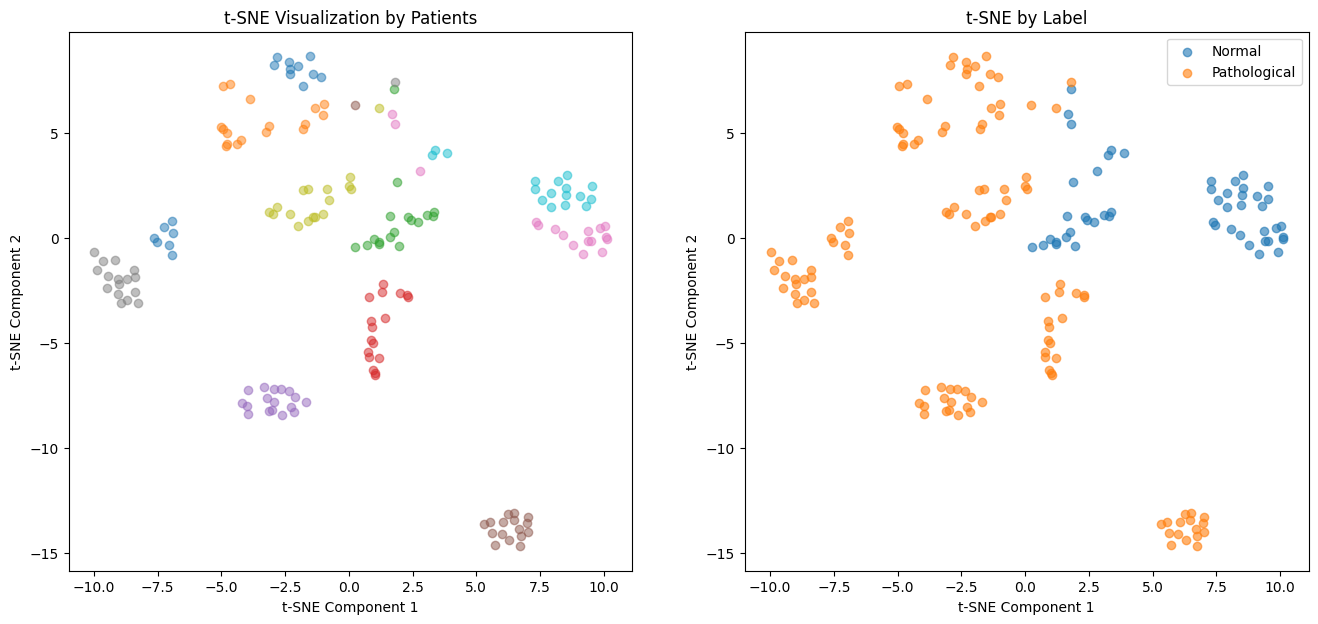

In [81]:
# Apply t-SNE to reduce embeddings to 2D
tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(embeddings)

normal_labels = np.array(labels)

embeddings_normal = embeddings_2d[normal_labels == 0]
embeddings_pathological = embeddings_2d[normal_labels == 1]

# Create scatter plot with labels as colors
fig, (ax_patients, ax_labels) = plt.subplots(1, 2, figsize=(16, 7))

# Right: class labels
ax_labels.scatter(embeddings_normal[:, 0], embeddings_normal[:, 1], alpha=0.6, label="Normal")
ax_labels.scatter(embeddings_pathological[:, 0], embeddings_pathological[:, 1], alpha=0.6, label="Pathological")
ax_labels.set_xlabel("t-SNE Component 1")
ax_labels.set_ylabel("t-SNE Component 2")
ax_labels.set_title("t-SNE by Label")
ax_labels.legend()

# Left: patient-wise plotting (keep current axis for the loop below)
ax_patients.scatter([], [], alpha=0.5, label="Patient windows")
plt.sca(ax_patients)
for k in range(0, len(embeddings_2d), N_WINDOWS):
    plt.scatter(embeddings_2d[k:k+N_WINDOWS, 0], embeddings_2d[k:k+N_WINDOWS, 1], alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization by Patients')
plt.show()